In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

sys.path.append(os.path.expanduser('~/git/desi-examples/imaging_systematics'))
from plot_healpix_map import plot_map

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
plot_dir = '/global/cfs/cdirs/desi/users/rongpu/lrg_xcorr/specz_variation/'

## Spec-z stats

In [4]:
hp_table = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/misc/lrg_pzbins_specz_stats.fits'))

In [5]:
hp_table[:5]

HPXPIXEL,RA,DEC,bin_1_z_mean,bin_1_z_median,bin_1_z_l68,bin_1_z_u68,bin_1_z_l95,bin_1_z_u95,bin_1_n_objects,bin_2_z_mean,bin_2_z_median,bin_2_z_l68,bin_2_z_u68,bin_2_z_l95,bin_2_z_u95,bin_2_n_objects,bin_3_z_mean,bin_3_z_median,bin_3_z_l68,bin_3_z_u68,bin_3_z_l95,bin_3_z_u95,bin_3_n_objects,bin_4_z_mean,bin_4_z_median,bin_4_z_l68,bin_4_z_u68,bin_4_z_l95,bin_4_z_u95,bin_4_n_objects
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64
94,135.0,79.75282793472046,0.49065221734881576,0.5207924867740714,0.4497928632448422,0.5340960722410563,0.3638116738410925,0.5455951189613477,8,0.6572841280494125,0.6734011869974957,0.6231617597252288,0.6832356549538448,0.5599632739161402,0.7266776633471368,8,0.8160003085644296,0.7886405444549873,0.7779723366995669,0.8733418384850334,0.7717288162885566,0.9215327320129173,8,0.9366702716481231,0.9387202241480026,0.8423689357939524,1.038119446945124,0.7614625817267415,1.15926410546318,14
123,129.375,78.28414760510762,0.4761076137235805,0.5192819529602156,0.4074521762758841,0.5337687279081627,0.35483195008169316,0.5367686953506453,10,0.629715482739571,0.6386050416697808,0.5472519902007732,0.696383104534885,0.5202243132870783,0.7535193120119279,21,0.791463529971662,0.7814384669333291,0.7393313281255565,0.8368210251924997,0.6765998460205495,0.9562417710697275,19,0.9037918717925071,0.9157204653433436,0.8343411500891504,0.9637000602445874,0.6882435645565712,1.0734957265777019,23
124,140.625,78.28414760510762,0.46631395794088176,0.47905506797423425,0.415880882559346,0.5111077351876057,0.39236747467266664,0.5524617430182678,28,0.6460013042921449,0.6417559867420589,0.5760560596077583,0.717985582982699,0.5277831726891629,0.7867539479822738,82,0.7803694453605667,0.7863828691934651,0.720055699672761,0.8563338656100268,0.645779449829327,0.903679815724297,90,0.930301979062657,0.9066727332361865,0.8339349175891989,1.0342063920649807,0.8086884621112747,1.112800568013156,43
156,125.00000000000001,76.81353334098655,0.46679188486419626,0.47638670246713544,0.41035838798418356,0.5124180722557461,0.3797220514041519,0.5344792465237276,22,0.6330346329131857,0.6302577633169492,0.5709134843879762,0.6943106987772769,0.5432151651173438,0.7808181151290807,70,0.7694383147844811,0.7754689015356596,0.7131269350915816,0.8315915788439358,0.6277807375548594,0.9585329904050359,44,0.9441152756854992,0.9523830272951608,0.861056693025354,0.9957394003535547,0.7568710062176701,1.2223625196431558,46
157,135.0,76.81353334098655,0.48103031183324924,0.4961324648955217,0.4182678336079091,0.5401810686605499,0.3981190744253494,0.5517829423549601,59,0.636611215925662,0.637610840332142,0.5542809478196101,0.706278096398746,0.5367548427281699,0.7527175212127604,100,0.7881304251521577,0.7815855826019057,0.7380948189676406,0.858846067660607,0.6371772108339103,0.9105144624485885,95,0.9081979002448605,0.8977746348160429,0.839758140409889,0.9764389301823316,0.7928968005773893,1.0838772906980674,77


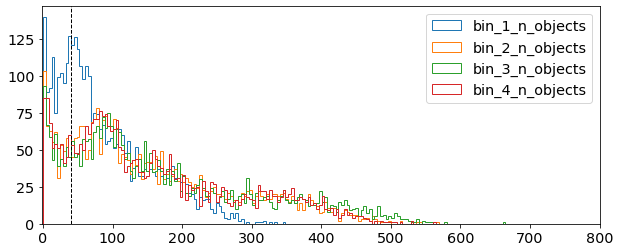

In [6]:
plt.figure(figsize=(10, 4))
for pz_bin in range(1, 5):
    xx = hp_table['bin_{}_n_objects'.format(pz_bin)]
    xx = xx[xx>0]
    bins = np.arange(xx.min()-0.5, xx.max()+1.5, 4)  # without gaps
    plt.hist(xx, bins=bins, histtype='step', label='bin_{}_n_objects'.format(pz_bin))
plt.legend()
plt.axvline(40, lw=1, ls='--', color='k')
plt.xlim(-2, 800)
plt.show()

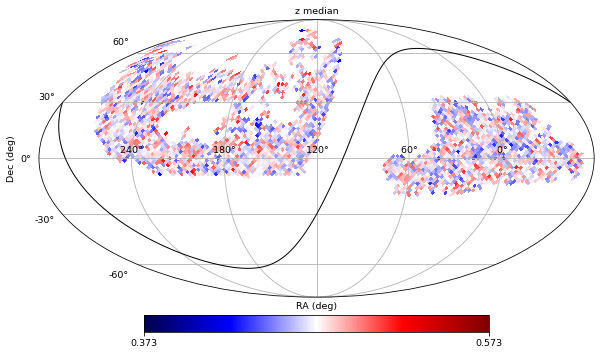

Done! 00:00:05


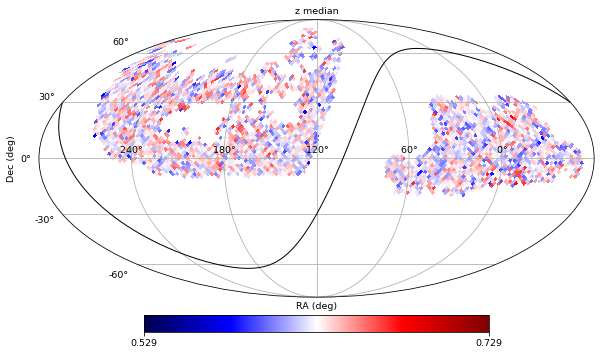

Done! 00:00:05


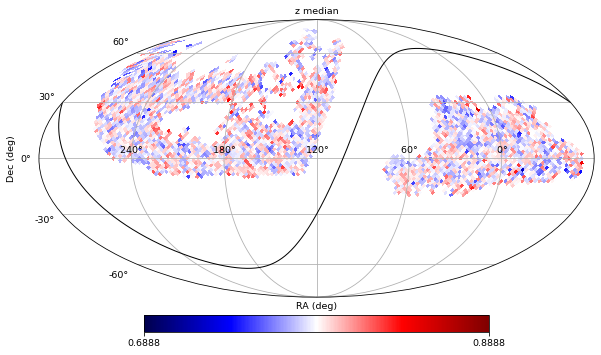

Done! 00:00:05


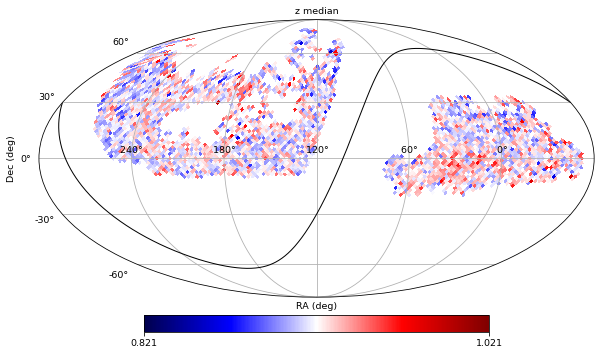

Done! 00:00:04


In [7]:
nside = 32

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'z_median'][mask])-0.1, np.median(hp_table[bin_str+'z_median'][mask])+0.1
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_median'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='z median', save_path=plot_dir+'lrg_pz_bin_{}_z_median_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax)
    
for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'z_mean'][mask])-0.1, np.median(hp_table[bin_str+'z_mean'][mask])+0.1
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_mean'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='z mean', save_path=plot_dir+'lrg_pz_bin_{}_z_mean_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'z_u68'][mask])-0.1, np.median(hp_table[bin_str+'z_u68'][mask])+0.1
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_u68'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='z upper bound of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_u68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'z_l68'][mask])-0.1, np.median(hp_table[bin_str+'z_l68'][mask])+0.1
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_l68'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='z lower bound of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_l68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median((hp_table[bin_str+'z_u68']-hp_table[bin_str+'z_l68'])[mask])-0.05, np.median((hp_table[bin_str+'z_u68']-hp_table[bin_str+'z_l68'])[mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array((hp_table[bin_str+'z_u68']-hp_table[bin_str+'z_l68'])[mask]).astype(float), dpi=100, xsize=2000, cmap='viridis',
             title='z width of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_w68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median(hp_table[bin_str+'z_u95'][mask])-0.1, np.median(hp_table[bin_str+'z_u95'][mask])+0.1
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_u95'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
#              title='z upper bound of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_u95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median(hp_table[bin_str+'z_l95'][mask])-0.1, np.median(hp_table[bin_str+'z_l95'][mask])+0.1
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_l95'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
#              title='z lower bound of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_l95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median((hp_table[bin_str+'z_u95']-hp_table[bin_str+'z_l95'])[mask])-0.05, np.median((hp_table[bin_str+'z_u95']-hp_table[bin_str+'z_l95'])[mask])+0.05
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array((hp_table[bin_str+'z_u95']-hp_table[bin_str+'z_l95'])[mask]).astype(float), dpi=100, xsize=2000, cmap='viridis',
#              title='z width of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_z_w95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

-------
# dz stats

In [8]:
hp_table = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/misc/lrg_pzbins_dz_stats.fits'))

In [9]:
hp_table[:5]

HPXPIXEL,RA,DEC,bin_1_dz_mean,bin_1_dz_median,bin_1_dz_l68,bin_1_dz_u68,bin_1_dz_l95,bin_1_dz_u95,bin_1_n_objects,bin_2_dz_mean,bin_2_dz_median,bin_2_dz_l68,bin_2_dz_u68,bin_2_dz_l95,bin_2_dz_u95,bin_2_n_objects,bin_3_dz_mean,bin_3_dz_median,bin_3_dz_l68,bin_3_dz_u68,bin_3_dz_l95,bin_3_dz_u95,bin_3_n_objects,bin_4_dz_mean,bin_4_dz_median,bin_4_dz_l68,bin_4_dz_u68,bin_4_dz_l95,bin_4_dz_u95,bin_4_n_objects
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64
94,135.0,79.75282793472046,-0.012085442612169414,-0.0015215620133243735,-0.050056089048553805,0.01996557504124576,-0.06712254149594554,0.025578158116764935,8,0.003232474008599079,0.0085672291584028,-0.023760712335993136,0.05198004973305006,-0.07932168253909047,0.0564744750750007,8,0.01672806190562759,0.022764522128870923,-0.05137042521133074,0.0419968732970176,-0.0590154128165373,0.11999356723134688,8,0.019179040002266588,0.01845243041860145,-0.06682338073818254,0.083273007749553,-0.12738795387253196,0.1565731554271312,14
123,129.375,78.28414760510762,-0.006229032594855177,0.00257548635889987,-0.04332491780358268,0.03175275835793999,-0.09386486216057634,0.0433307381429602,10,0.0019399867789721401,-0.012181067081684982,-0.03333318258400129,0.039002834160826484,-0.048236149426356845,0.06785881023641038,21,-0.013297973900456476,-0.03184518288678373,-0.04966222492140701,0.022751291839193156,-0.09348885999930495,0.13144283839818055,19,-0.0030021112937885785,-0.02166418552281746,-0.04111766053485058,0.05318011361128077,-0.19317723255303265,0.15728051000767235,23
124,140.625,78.28414760510762,-0.0043447701137098215,-0.0005126274028031397,-0.038378292308781044,0.023571517556133532,-0.058068388017543715,0.040333813004306815,28,0.007085644841241684,0.009534522027270897,-0.016114279761664022,0.04929247700072396,-0.12624929698713158,0.13619320516155914,82,-0.014649247450763299,-0.010753079881254346,-0.04428635143047965,0.04728354757893735,-0.17762997936321598,0.09807206718165784,90,0.012161567685703823,0.012606756487184123,-0.0695604855903556,0.0831148970088284,-0.10505587065461267,0.1569530818236119,43
156,125.00000000000001,76.81353334098655,-0.004481689097928621,-0.0021665389270787982,-0.01949223169821329,0.011641327062812096,-0.056831906543457024,0.027249543930070032,22,0.004183412475727246,-0.0037965263467022448,-0.0274416781482056,0.04653047237184014,-0.05144714202824681,0.08330804764351626,70,-0.01799461996572899,-0.011167693386557764,-0.05450578167724983,0.03369484680477775,-0.1881033766333337,0.15869208120385755,44,0.026620185656985283,0.020800207670654547,-0.023094980771699,0.10561866399648218,-0.14804501328288305,0.28977259379570186,46
157,135.0,76.81353334098655,3.47805288412907e-05,0.003730697130018501,-0.02354399704929447,0.021234540943980845,-0.06512285323781031,0.07221515970676479,59,0.003655208206622215,-0.003724285537817673,-0.03689352674754884,0.04276111121668787,-0.09448680882823696,0.08076362668869283,100,-0.004729893960318846,-0.00014978805772380976,-0.0541500734478363,0.059183975459169265,-0.13685695641202889,0.11431091534159626,95,-0.007408497068096593,-0.0014407702319763072,-0.06721892075062225,0.05417515341671875,-0.17604543286512533,0.11882803858470323,77


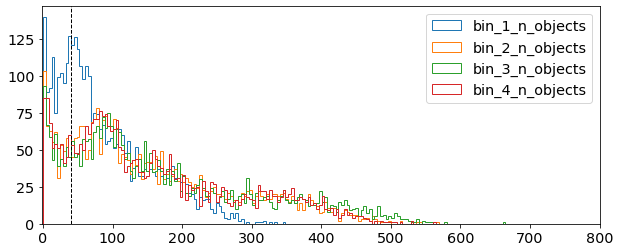

In [10]:
plt.figure(figsize=(10, 4))
for pz_bin in range(1, 5):
    xx = hp_table['bin_{}_n_objects'.format(pz_bin)]
    xx = xx[xx>0]
    bins = np.arange(xx.min()-0.5, xx.max()+1.5, 4)  # without gaps
    plt.hist(xx, bins=bins, histtype='step', label='bin_{}_n_objects'.format(pz_bin))
plt.legend()
plt.axvline(40, lw=1, ls='--', color='k')
plt.xlim(-2, 800)
plt.show()

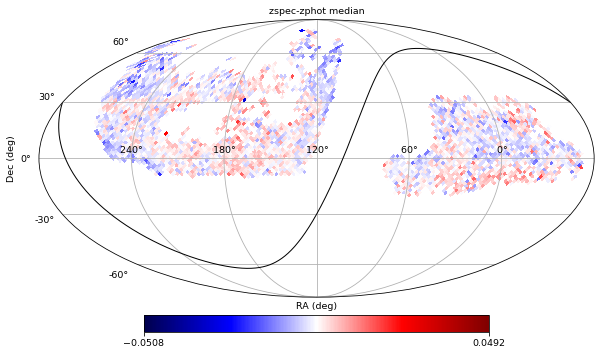

Done! 00:00:04


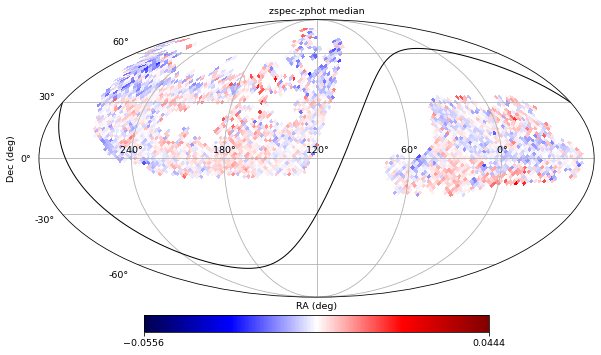

Done! 00:00:04


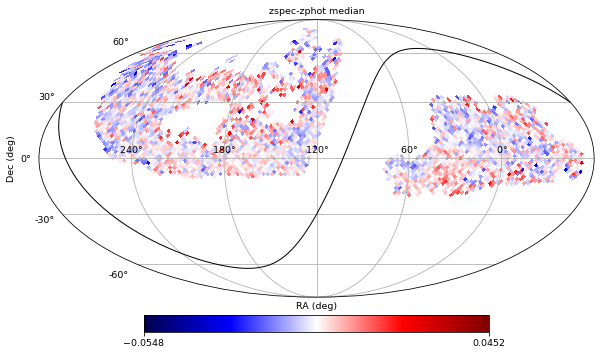

Done! 00:00:04


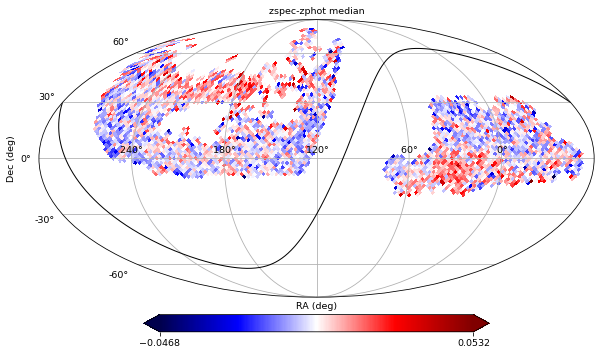

Done! 00:00:04


In [11]:
nside = 32

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'dz_median'][mask])-0.05, np.median(hp_table[bin_str+'dz_median'][mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_median'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='zspec-zphot median', save_path=plot_dir+'lrg_pz_bin_{}_dz_median_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax)
    
for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'dz_mean'][mask])-0.05, np.median(hp_table[bin_str+'dz_mean'][mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_mean'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='zspec-zphot mean', save_path=plot_dir+'lrg_pz_bin_{}_dz_mean_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'dz_u68'][mask])-0.05, np.median(hp_table[bin_str+'dz_u68'][mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_u68'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='zspec-zphot upper bound of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_u68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median(hp_table[bin_str+'dz_l68'][mask])-0.05, np.median(hp_table[bin_str+'dz_l68'][mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_l68'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='zspec-zphot lower bound of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_l68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>20
    vmin, vmax = np.median((hp_table[bin_str+'dz_u68']-hp_table[bin_str+'dz_l68'])[mask])-0.05, np.median((hp_table[bin_str+'dz_u68']-hp_table[bin_str+'dz_l68'])[mask])+0.05
    plot_map(32, hp_table['HPXPIXEL'][mask], np.array((hp_table[bin_str+'dz_u68']-hp_table[bin_str+'dz_l68'])[mask]).astype(float), dpi=100, xsize=2000, cmap='viridis',
             title='zspec-zphot width of 68% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_w68_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median(hp_table[bin_str+'dz_u95'][mask])-0.05, np.median(hp_table[bin_str+'dz_u95'][mask])+0.05
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_u95'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
#              title='zspec-zphot upper bound of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_u95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median(hp_table[bin_str+'dz_l95'][mask])-0.05, np.median(hp_table[bin_str+'dz_l95'][mask])+0.05
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'dz_l95'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
#              title='zspec-zphot lower bound of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_l95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

# for pz_bin in range(1, 5):
#     bin_str = 'bin_'+str(pz_bin)+'_'
#     mask = hp_table[bin_str+'n_objects']>20
#     vmin, vmax = np.median((hp_table[bin_str+'dz_u95']-hp_table[bin_str+'dz_l95'])[mask])-0.05, np.median((hp_table[bin_str+'dz_u95']-hp_table[bin_str+'dz_l95'])[mask])+0.05
#     plot_map(32, hp_table['HPXPIXEL'][mask], np.array((hp_table[bin_str+'dz_u95']-hp_table[bin_str+'dz_l95'])[mask]).astype(float), dpi=100, xsize=2000, cmap='viridis',
#              title='zspec-zphot width of 95% interval', save_path=plot_dir+'lrg_pz_bin_{}_dz_w95_{}.png'.format(pz_bin, nside), vmin=vmin, vmax=vmax, timing=False, show=False)

In [18]:
hp_table = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/misc/lrg_pzbins_specz_stats_16.fits'))

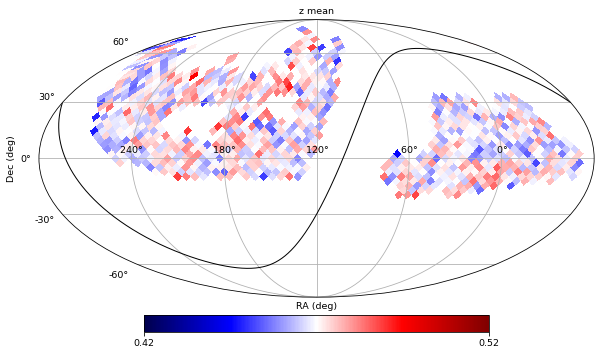

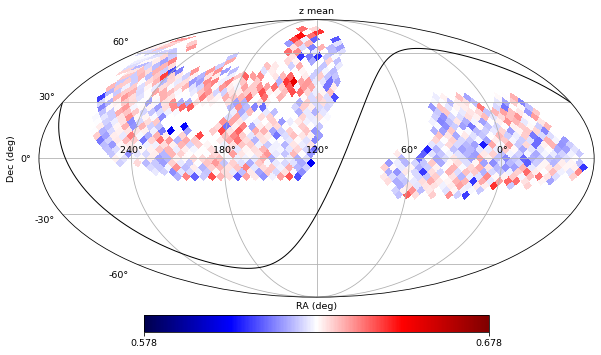

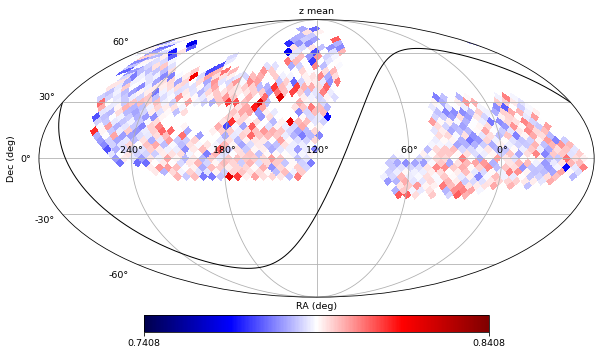

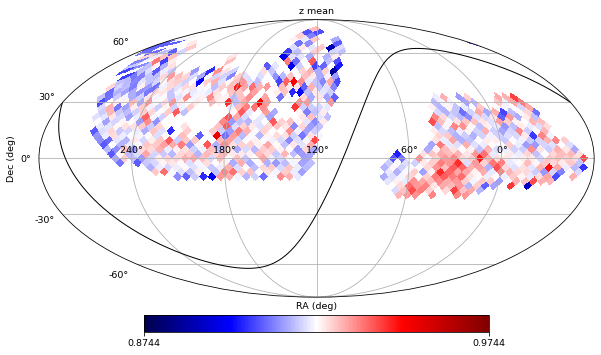

In [20]:
for pz_bin in range(1, 5):
    bin_str = 'bin_'+str(pz_bin)+'_'
    mask = hp_table[bin_str+'n_objects']>40
    vmin, vmax = np.median(hp_table[bin_str+'z_mean'][mask])-0.05, np.median(hp_table[bin_str+'z_mean'][mask])+0.05
    plot_map(16, hp_table['HPXPIXEL'][mask], np.array(hp_table[bin_str+'z_mean'][mask]).astype(float), dpi=100, xsize=2000, cmap='seismic',
             title='z mean', vmin=vmin, vmax=vmax, timing=False, show=True)